<a href="https://colab.research.google.com/github/emanuelmejia/course_time_series_python/blob/main/L07-Modelos_ARIMA/notebooks/L07_1_ModeloIntegrado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as smt # para gráficos ACF y PACF

# **Modelo Integrado**

In [2]:
# Crear Caminata mediante suma acumulativa
# Crear 1000 puntos de una distribución normal estándar
w = np.random.randn(1000)
df = pd.DataFrame()
df['walk'] = w.cumsum()
df.head(10)

,walk
0,-0.318213
1,2.443509
2,2.855942
3,2.307320
4,3.342019
5,3.145922
6,3.160790
7,4.752125
8,4.727084
9,3.720687


In [3]:
df['diff'] = df['walk'].diff()
df.head(10)

,walk,diff
0,-0.318213,NaN
1,2.443509,2.761722
2,2.855942,0.412433
3,2.307320,-0.548621
4,3.342019,1.034699
5,3.145922,-0.196097
6,3.160790,0.014868
7,4.752125,1.591335
8,4.727084,-0.025041
9,3.720687,-1.006397


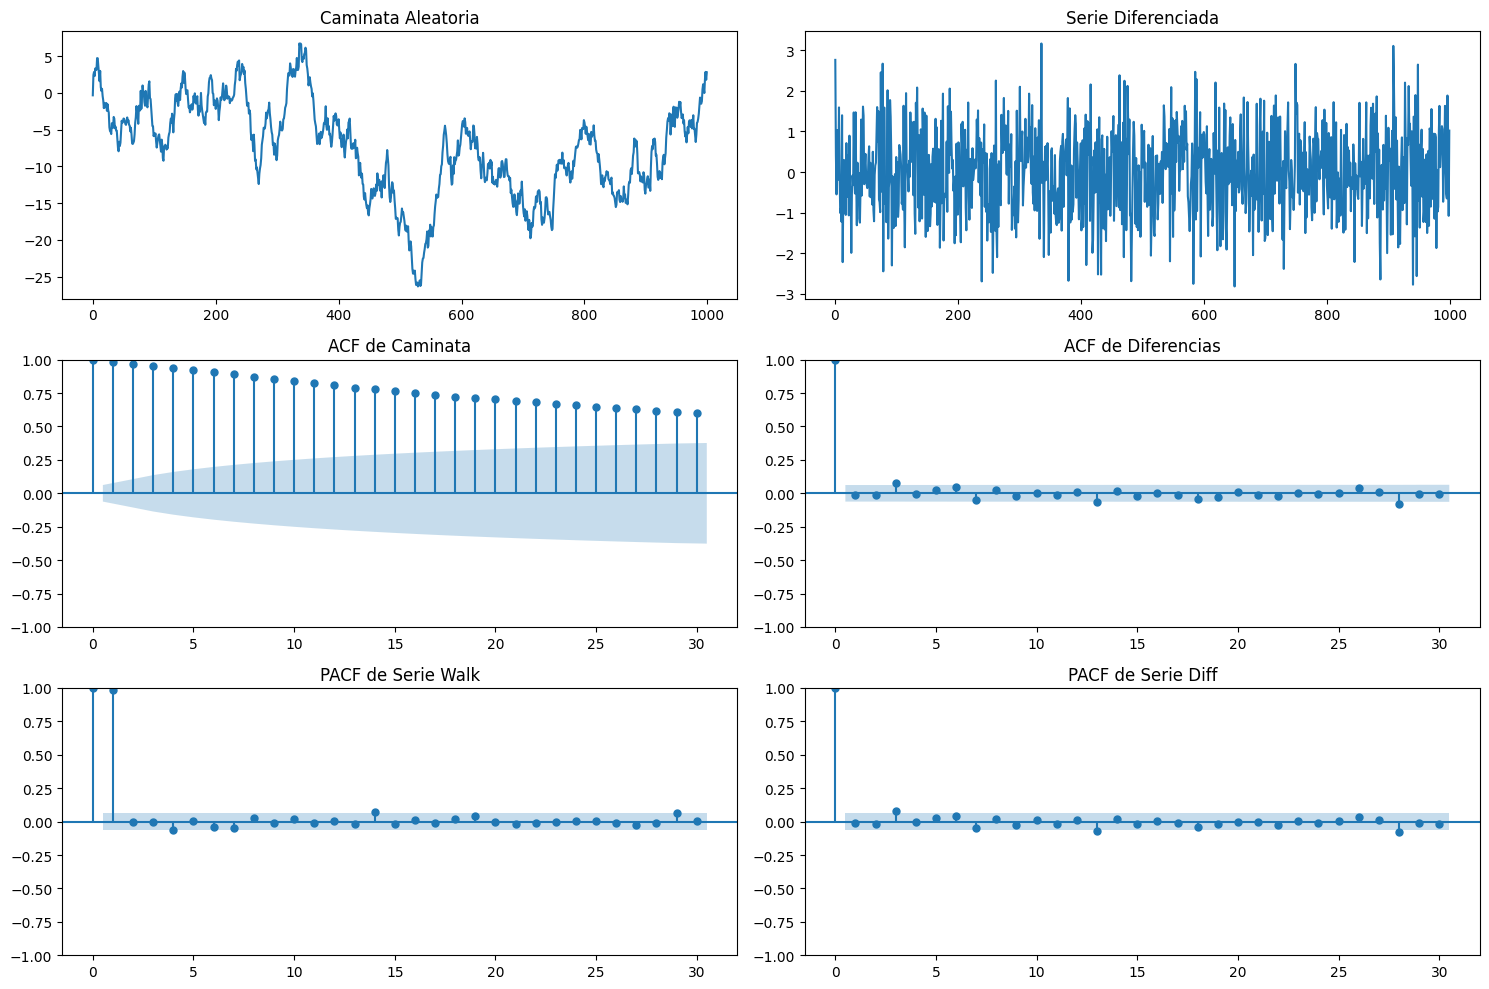

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(15, 10))

# Row 1: Line plots
axes[0, 0].plot(df['walk'])
axes[0, 0].set_title('Caminata Aleatoria')
axes[0, 1].plot(df['diff'])
axes[0, 1].set_title('Serie Diferenciada')

# Row 2: ACF plots
smt.plot_acf(df['walk'], ax=axes[1, 0])
axes[1, 0].set_title('ACF de Caminata')
smt.plot_acf(df['diff'].dropna(), ax=axes[1, 1]) # Quitar NaN para serie diferenciada
axes[1, 1].set_title('ACF de Diferencias')

# Row 3: PACF plots
smt.plot_pacf(df['walk'], ax=axes[2, 0])
axes[2, 0].set_title('PACF de Serie Walk')
smt.plot_pacf(df['diff'].dropna(), ax=axes[2, 1]) # Quitar NaN para serie diferenciada
axes[2, 1].set_title('PACF de Serie Diff')

plt.tight_layout()
plt.show()